# Segmentation Recall Analysis

Analyse the CSV outputs produced by `evaluate_recall.py`.

**Inputs** (in `scripts/segmentation_strategies/results/`):

| File | Contents |
|------|----------|
| `recall_per_question_*.csv` | One row per (question, strategy) — rank, recall@k, coverage |
| `recall_aggregate_*.csv` | One row per strategy — averaged metrics |

Run the script first:
```bash
cd <repo-root>
python scripts/segmentation_strategies/evaluate_recall.py
```

In [30]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import glob
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple

from scripts.segmentation_strategies.evaluate import (
    coverage_score,
    load_records,
    retrieval_rank,
)

REPO_ROOT = os.getcwd()
RESULTS_DIR = os.path.join(REPO_ROOT, "scripts", "segmentation_strategies", "results")

SCRIPTS_DIR = os.path.join(REPO_ROOT, "scripts")
CLUSTER_DIR = os.path.join(REPO_ROOT, "data", "cluster_questions")
OUTPUT_DIR = os.path.join(SCRIPTS_DIR, "results")

# Auto-detect the latest result files
per_q_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "recall_per_question_*.csv")))
agg_files   = sorted(glob.glob(os.path.join(RESULTS_DIR, "recall_aggregate_*.csv")))

if not per_q_files:
    raise FileNotFoundError(f"No per-question CSV found in {RESULTS_DIR}. Run evaluate_recall.py first.")

PER_Q_PATH = per_q_files[-1]   # latest
AGG_PATH   = agg_files[-1]     # latest
print(f"Per-question CSV : {os.path.basename(PER_Q_PATH)}")
print(f"Aggregate CSV    : {os.path.basename(AGG_PATH)}")

Per-question CSV : recall_per_question_20260319_152848.csv
Aggregate CSV    : recall_aggregate_20260319_152848.csv


In [31]:
def load_all_records(cluster_dir: Path) -> List[Dict]:
    """Load and merge all cluster JSON files."""
    records: List[Dict] = []
    pattern = os.path.join(cluster_dir, "clusters_*_for_llm.json")
    for fpath in sorted(glob.glob(pattern)):
        fname = os.path.basename(fpath)
        recs = load_records(fpath)
        # Tag each record with the cluster file it came from
        for r in recs:
            r["_source_file"] = fname
        records.extend(recs)
    return records


all_records = load_all_records(CLUSTER_DIR)
valid = [r for r in all_records if r.get("doc_2") and r.get("doc_2_section")]
valid = [r for r in all_records if r.get("source_2")=="Les Débats"]



## 1. Load data

In [32]:
df = pd.read_csv(PER_Q_PATH)
df_agg = pd.read_csv(AGG_PATH)

print(f"Per-question rows : {len(df)}")
print(f"Strategies        : {df['strategy'].nunique()}")
print(f"Questions         : {df['question'].nunique()}")
print(f"Clusters          : {df['cluster'].nunique()}")
print()
df_agg.sort_values("recall@3", ascending=False)

Per-question rows : 4941
Strategies        : 9
Questions         : 549
Clusters          : 29



,strategy,n_questions,coverage_rate,mean_rank,avg_segments,recall@1,recall@3,recall@5,recall@10
0,S1_header_based,549,1.000000,0.000000,1.016393,1.000000,1.000000,1.000000,1.000000
5,S5_anchor_ctx0,549,1.000000,0.240437,2.734062,0.792350,1.000000,1.000000,1.000000
6,S5_anchor_ctx1,549,1.000000,0.258652,2.717668,0.777778,1.000000,1.000000,1.000000
7,S5_anchor_ctx2,549,1.000000,0.251366,2.717668,0.774135,1.000000,1.000000,1.000000
8,S8_chapter_vote,549,1.000000,0.116576,6.792350,0.925319,0.992714,0.998179,1.000000
3,S3_speaker_window_5,549,0.994536,1.386447,13.411658,0.533698,0.799636,0.905282,0.979964
4,S4_president_mediated,549,0.994536,1.738095,14.067395,0.533698,0.770492,0.863388,0.952641
2,S3_speaker_window_3,549,0.994536,2.868132,26.273224,0.409836,0.672131,0.794171,0.918033
1,S2_speaker_atomic,549,0.970856,5.669794,52.153005,0.322404,0.579235,0.679417,0.803279


## 2. Aggregate recall bar chart

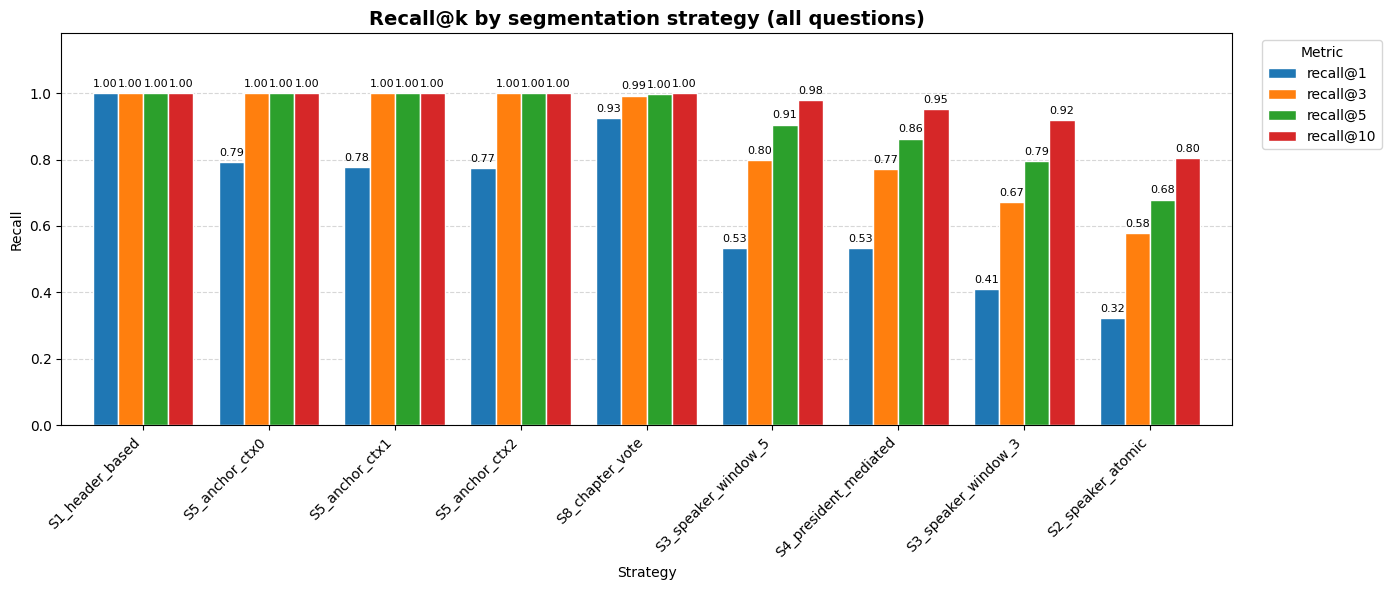

In [33]:
recall_cols = [c for c in df_agg.columns if c.startswith("recall@")]
df_plot = df_agg.set_index("strategy")[recall_cols].sort_values(recall_cols[-1], ascending=False)

ax = df_plot.plot(kind="bar", figsize=(14, 6), width=0.8, edgecolor="white")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)

ax.set_title("Recall@k by segmentation strategy (all questions)", fontsize=14, fontweight="bold")
ax.set_ylabel("Recall")
ax.set_xlabel("Strategy")
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, df_plot.values.max() * 1.18)
plt.tight_layout()
plt.show()

## 3. Coverage rate

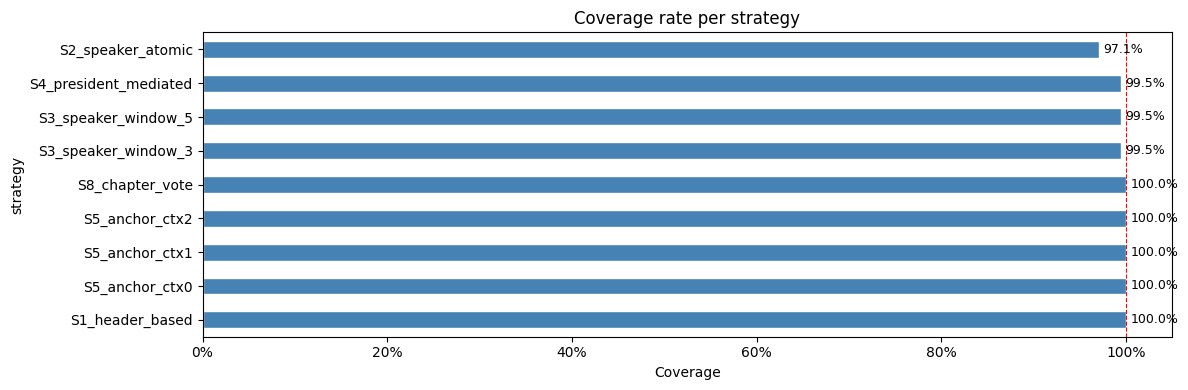

In [34]:
cov = df_agg.set_index("strategy")["coverage_rate"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
cov.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlim(0, 1.05)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.axvline(1.0, color="red", linestyle="--", linewidth=0.8)
ax.set_title("Coverage rate per strategy")
ax.set_xlabel("Coverage")
for i, v in enumerate(cov):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 4. Mean rank distribution

C:\Users\plathoon\AppData\Local\Temp\ipykernel_19020\3331958959.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, vert=True, patch_artist=True, labels=strategies_ordered)


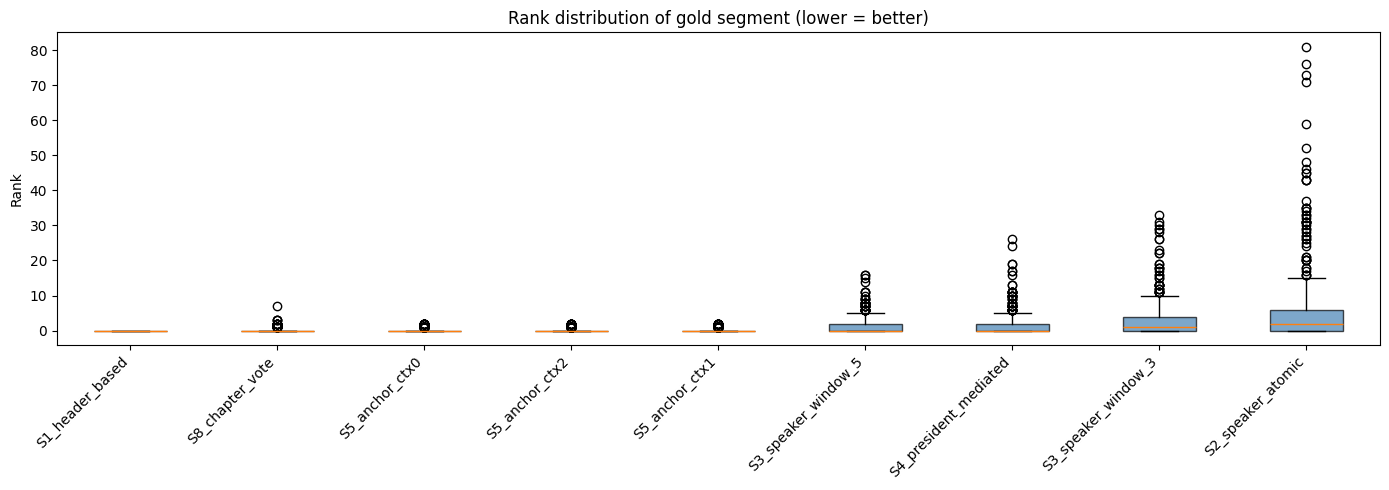

In [35]:
# Rank distribution per strategy (excluding rank == -1 = not found)
valid_ranks = df[df["rank"] >= 0]

fig, ax = plt.subplots(figsize=(14, 5))
strategies_ordered = df_agg.sort_values("mean_rank")["strategy"].tolist()
bp_data = [valid_ranks[valid_ranks["strategy"] == s]["rank"].values for s in strategies_ordered]

bp = ax.boxplot(bp_data, vert=True, patch_artist=True, labels=strategies_ordered)
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.7)

ax.set_title("Rank distribution of gold segment (lower = better)")
ax.set_ylabel("Rank")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Per-cluster breakdown

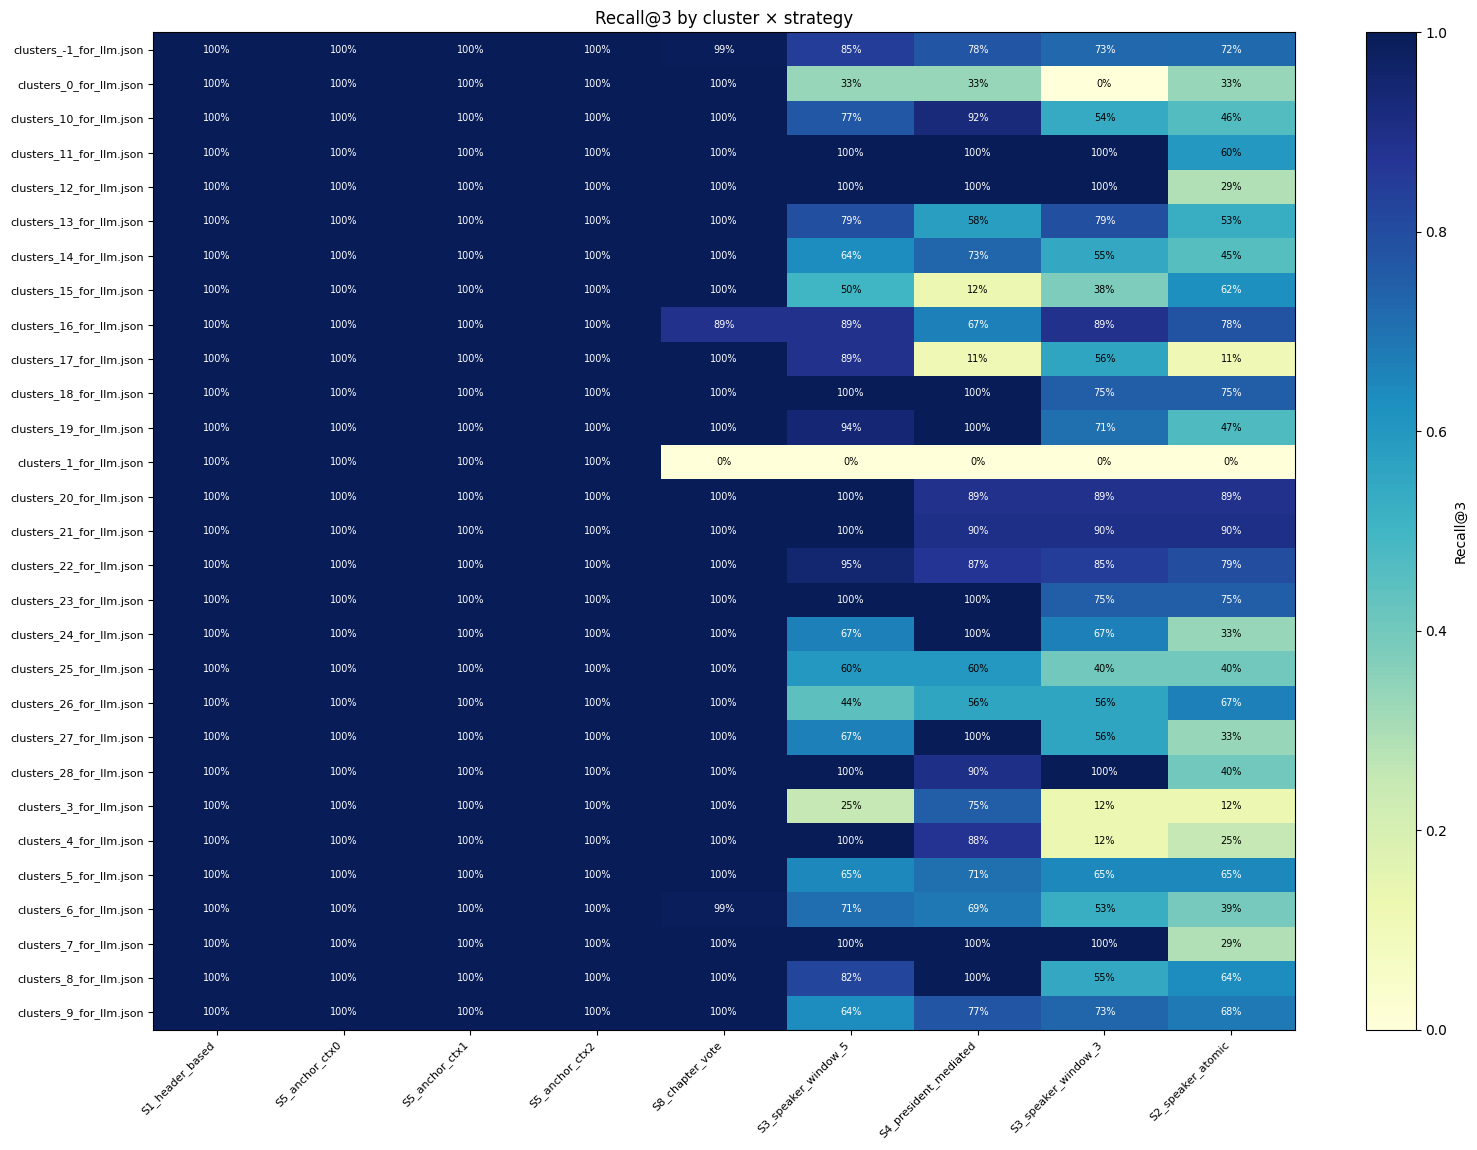

In [36]:
# Recall@3 per cluster per strategy — heatmap
pivot = df.groupby(["cluster", "strategy"])["recall@3"].mean().unstack(fill_value=0)
# Sort by cluster name and strategy by global recall@3
strat_order = df_agg.sort_values("recall@3", ascending=False)["strategy"].tolist()
pivot = pivot[[s for s in strat_order if s in pivot.columns]]

fig, ax = plt.subplots(figsize=(16, max(6, len(pivot) * 0.4)))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_title("Recall@3 by cluster × strategy")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        color = "white" if val > 0.6 else "black"
        ax.text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=7, color=color)

plt.colorbar(im, ax=ax, label="Recall@3")
plt.tight_layout()
plt.show()

## 6. Segment count vs recall trade-off

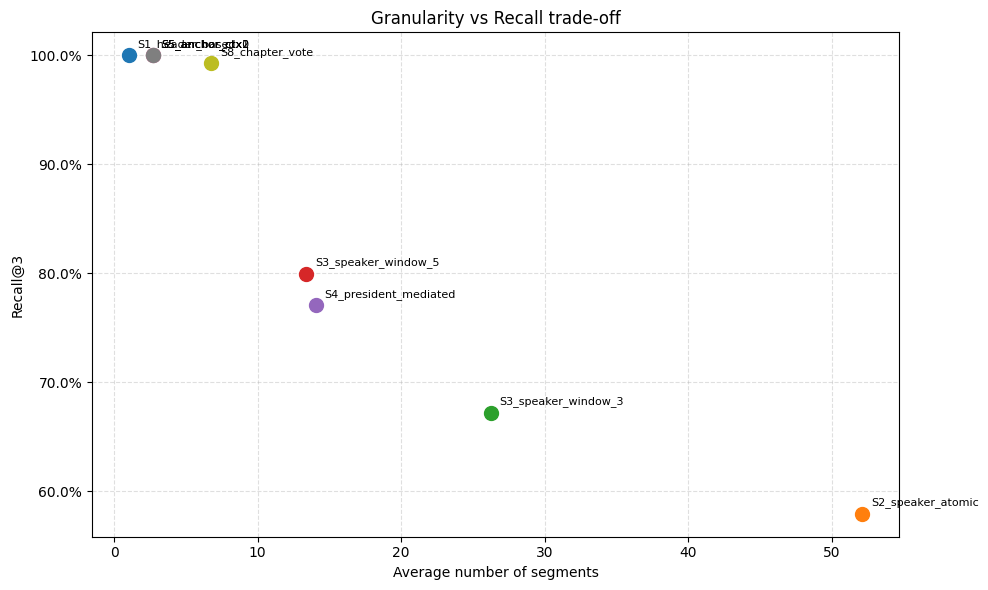

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
for _, row in df_agg.iterrows():
    ax.scatter(row["avg_segments"], row["recall@3"], s=100, zorder=5)
    ax.annotate(row["strategy"], (row["avg_segments"], row["recall@3"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8)

ax.set_xlabel("Average number of segments")
ax.set_ylabel("Recall@3")
ax.set_title("Granularity vs Recall trade-off")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Failure analysis — questions with rank == -1 (not found)

In [38]:
# Which strategy × cluster combinations have the most failures?
failures = df[df["rank"] == -1]
print(f"Total failure rows: {len(failures)} / {len(df)}")
print()

fail_summary = (
    failures.groupby(["strategy", "cluster"])
    .size()
    .reset_index(name="n_failures")
    .sort_values("n_failures", ascending=False)
)
fail_summary.head(20)

Total failure rows: 25 / 4941



,strategy,cluster,n_failures
1,S2_speaker_atomic,clusters_10_for_llm.json,3
3,S2_speaker_atomic,clusters_19_for_llm.json,3
6,S2_speaker_atomic,clusters_6_for_llm.json,3
7,S3_speaker_window_3,clusters_6_for_llm.json,3
8,S3_speaker_window_5,clusters_6_for_llm.json,3
9,S4_president_mediated,clusters_6_for_llm.json,3
0,S2_speaker_atomic,clusters_-1_for_llm.json,2
2,S2_speaker_atomic,clusters_18_for_llm.json,2
5,S2_speaker_atomic,clusters_3_for_llm.json,2
4,S2_speaker_atomic,clusters_22_for_llm.json,1


In [39]:
# Sample questions that fail across multiple strategies
fail_counts = failures.groupby("question")["strategy"].count().reset_index(name="n_strategies_failed")
worst = fail_counts.sort_values("n_strategies_failed", ascending=False).head(10)
print("Questions failing the most strategies:")
for _, row in worst.iterrows():
    print(f"  [{row['n_strategies_failed']} strategies failed]  {row['question'][:120]}")

Questions failing the most strategies:
  [4 strategies failed]  Comment M. de Lamarzelle justifie-t-il son opposition au projet de loi militaire en termes d'impact sur l'enseignement p
  [4 strategies failed]  En 1887, quels arguments M. de Lamarzelle avance-t-il à la Chambre contre le projet de loi militaire, et comment la pres
  [4 strategies failed]  Selon M. de Lamarzelle, en quoi la loi militaire proposée néglige-t-elle un aspect crucial de la compétition entre natio
  [1 strategies failed]  Comment M. Dugué de la Fauconnerie perçoit-il l'état de la politique en France en 1887, et quelle est la réaction de la 
  [1 strategies failed]  Comment M. Raynal justifie-t-il l'absence de besoin de modifier le mode d'élection du Sénat, et quelle est la réaction d
  [1 strategies failed]  En 1887, comment M. Dugué de la Fauconnerie critique-t-il les pratiques électorales dans son discours, et quelle est la 
  [1 strategies failed]  En 1887, comment M. Wilson critique-t-il la gestion du budge

## 8. Summary table

Final aggregate table for the README / paper.

In [41]:
summary_cols = ["strategy", "n_questions", "coverage_rate", "avg_segments", "mean_rank"] + recall_cols
summary = df_agg[summary_cols].sort_values("recall@3", ascending=False)
summary["coverage_rate"] = summary["coverage_rate"].map("{:.1%}".format)
for c in recall_cols:
    summary[c] = summary[c].map("{:.2%}".format)
summary["mean_rank"] = summary["mean_rank"].map("{:.1f}".format)
summary["avg_segments"] = summary["avg_segments"].map("{:.1f}".format)

#print(summary.to_markdown(index=False))
summary

,strategy,n_questions,coverage_rate,avg_segments,mean_rank,recall@1,recall@3,recall@5,recall@10
0,S1_header_based,549,100.0%,1.0,0.0,100.00%,100.00%,100.00%,100.00%
5,S5_anchor_ctx0,549,100.0%,2.7,0.2,79.23%,100.00%,100.00%,100.00%
6,S5_anchor_ctx1,549,100.0%,2.7,0.3,77.78%,100.00%,100.00%,100.00%
7,S5_anchor_ctx2,549,100.0%,2.7,0.3,77.41%,100.00%,100.00%,100.00%
8,S8_chapter_vote,549,100.0%,6.8,0.1,92.53%,99.27%,99.82%,100.00%
3,S3_speaker_window_5,549,99.5%,13.4,1.4,53.37%,79.96%,90.53%,98.00%
4,S4_president_mediated,549,99.5%,14.1,1.7,53.37%,77.05%,86.34%,95.26%
2,S3_speaker_window_3,549,99.5%,26.3,2.9,40.98%,67.21%,79.42%,91.80%
1,S2_speaker_atomic,549,97.1%,52.2,5.7,32.24%,57.92%,67.94%,80.33%
